<a href="https://colab.research.google.com/github/ahmad-goudah/alfaisalx-medmnist-challenge/blob/main/notebooks/AlfaisalX_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages

!pip -q install medmnist faiss-cpu scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00


In [2]:
# Imports + folders + seed

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# Make sure folders exist in the repo structure
os.makedirs("models", exist_ok=True)
os.makedirs("reports/task1", exist_ok=True)
os.makedirs("reports/task3", exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [7]:
#Load PneumoniaMNIST dataset

import medmnist
from medmnist import PneumoniaMNIST
from torchvision import transforms

# Basic transforms (simple & safe)
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # light augmentation (optional but good)
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28, scale=(0.9, 1.0)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = PneumoniaMNIST(split="train", transform=train_transform, download=True)
val_dataset   = PneumoniaMNIST(split="val", transform=test_transform, download=True)
test_dataset  = PneumoniaMNIST(split="test", transform=test_transform, download=True)

print("Train:", len(train_dataset),
      "Val:", len(val_dataset),
      "Test:", len(test_dataset))

#print("Num classes:", train_dataset.info["n_classes"])
print("Info dictionary:", train_dataset.info)
print("Task:", train_dataset.info["task"])
print("Image size:", train_dataset.info["n_channels"], "x", train_dataset.info["n_channels"], "(channel count shown separately)")





print("Dataset info keys:", train_dataset.info.keys())
# Try safe access
print("Task type:", train_dataset.info.get("task", "Not available"))
print("Number of classes:", train_dataset.info.get("label", "Binary classification"))
print("Number of channels:", train_dataset.info.get("n_channels", "Unknown"))

Train: 4708 Val: 524 Test: 624
Info dictionary: {'python_class': 'PneumoniaMNIST', 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.', 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1', 'MD5': '28209eda62fecd6e6a2d98b1501bb15f', 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1', 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6', 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1', 'MD5_128': '05b46931834c231683c68f40c47b2971', 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz

In [9]:
# Create Data Loaders

batch_size = 128  # good for CPU/GPU
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Check one batch
images, labels = next(iter(train_loader))
print("Batch images:", images.shape)   # [B, 1, 28, 28]
print("Batch labels:", labels.shape)   # [B, 1]
print("Unique labels in batch:", labels.unique())

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Batch images: torch.Size([128, 1, 28, 28])
Batch labels: torch.Size([128, 1])
Unique labels in batch: tensor([0, 1])


In [10]:
# Build a simple CNN model (fast)


class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 1)  # binary logit

    def forward(self, x, return_features=False):
        x = self.pool(F.relu(self.conv1(x)))  # 28->14
        x = self.pool(F.relu(self.conv2(x)))  # 14->7
        x = self.pool(F.relu(self.conv3(x)))  # 7->3
        x = x.view(x.size(0), -1)             # flatten
        x = self.dropout(x)
        feats = F.relu(self.fc1(x))
        logit = self.fc2(feats)
        if return_features:
            return logit, feats
        return logit

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [11]:
# Train + validate (save best model)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def predict_probs_and_labels(logits):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).long()
    return probs, preds

def evaluate(loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_true  = []
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()  # y shape [B,1]
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)

            probs, preds = predict_probs_and_labels(logits)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())

    all_probs = np.vstack(all_probs).ravel()
    all_preds = np.vstack(all_preds).ravel()
    all_true  = np.vstack(all_true).ravel()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, zero_division=0)
    rec  = recall_score(all_true, all_preds, zero_division=0)
    f1   = f1_score(all_true, all_preds, zero_division=0)

    # ROC-AUC needs probabilities, may fail if only one class appears
    try:
        auc = roc_auc_score(all_true, all_probs)
    except:
        auc = float("nan")

    return avg_loss, acc, prec, rec, f1, auc

epochs = 15
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_auc": []
}

best_val_auc = -1.0
best_path = "models/task1_best_cnn.pt"

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_prec, val_rec, val_f1, val_auc = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | val_auc={val_auc:.4f}")

    # Save best by AUC (if nan, fallback to F1)
    score = val_auc if not np.isnan(val_auc) else val_f1
    if score > best_val_auc:
        best_val_auc = score
        torch.save(model.state_dict(), best_path)
        print("  ✅ Saved best model:", best_path)

Epoch 01/15 | train_loss=0.5619 | val_loss=0.4817 | val_acc=0.7424 | val_f1=0.8521 | val_auc=0.8749
  ✅ Saved best model: models/task1_best_cnn.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 02/15 | train_loss=0.3171 | val_loss=0.2629 | val_acc=0.9008 | val_f1=0.9305 | val_auc=0.9613
  ✅ Saved best model: models/task1_best_cnn.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 03/15 | train_loss=0.2190 | val_loss=0.1825 | val_acc=0.9160 | val_f1=0.9429 | val_auc=0.9740
  ✅ Saved best model: models/task1_best_cnn.pt


...

Epoch 13/15 | train_loss=0.1247 | val_loss=0.1278 | val_acc=0.9485 | val_f1=0.9647 | val_auc=0.9915
  ✅ Saved best model: models/task1_best_cnn.pt


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 14/15 | train_loss=0.1288 | val_loss=0.1120 | val_acc=0.9599 | val_f1=0.9730 | val_auc=0.9903


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 15/15 | train_loss=0.1203 | val_loss=0.1239 | val_acc=0.9542 | val_f1=0.9687 | val_auc=0.9915


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TEST METRICS
Accuracy : 0.8910256410256411
Precision: 0.8833333333333333
Recall   : 0.9512820512820512
F1       : 0.9160493827160494
ROC-AUC  : 0.9486960333114179
Confusion matrix:
 [[185  49]
 [ 19 371]]


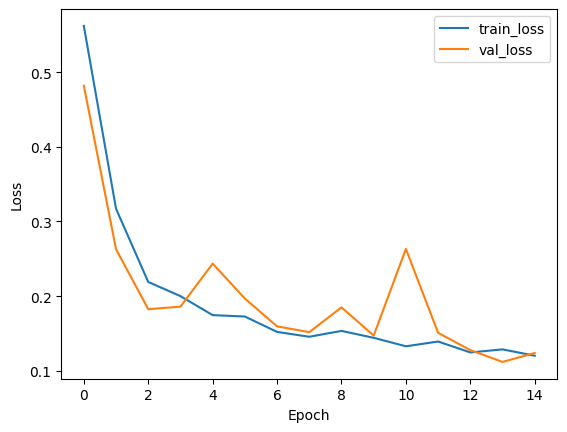

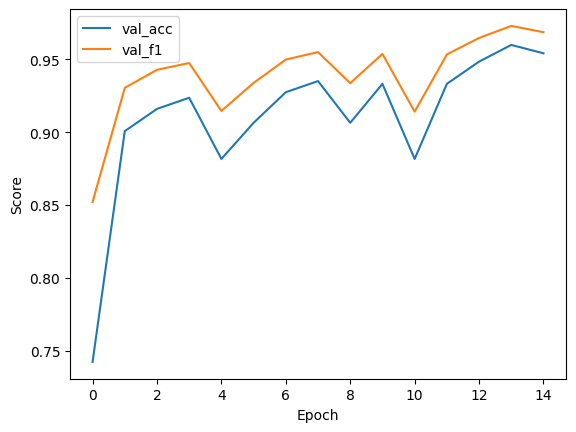

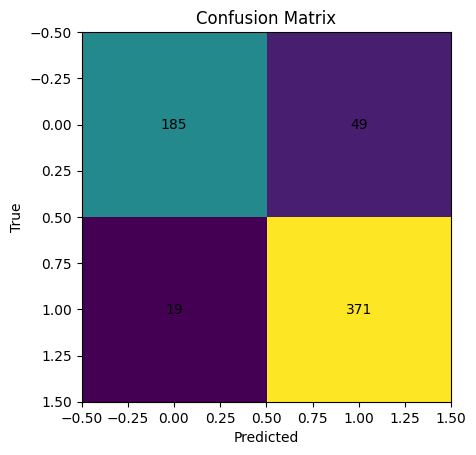

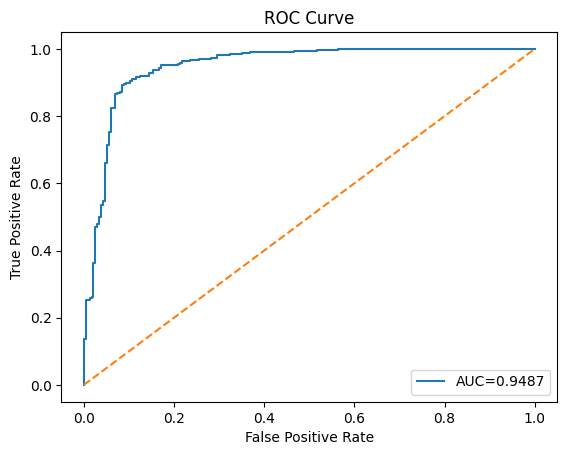

In [12]:
# Test evaluation + save metrics + plots

# Load best model
model.load_state_dict(torch.load("models/task1_best_cnn.pt", map_location=device))
model.eval()

def get_test_outputs(loader):
    all_probs, all_preds, all_true = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float()
            logits = model(x)
            probs, preds = predict_probs_and_labels(logits)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(y.cpu().numpy())
    all_probs = np.vstack(all_probs).ravel()
    all_preds = np.vstack(all_preds).ravel()
    all_true  = np.vstack(all_true).ravel()
    return all_true, all_preds, all_probs

y_true, y_pred, y_prob = get_test_outputs(test_loader)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
auc  = roc_auc_score(y_true, y_prob)

cm = confusion_matrix(y_true, y_pred)

print("TEST METRICS")
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1       :", f1)
print("ROC-AUC  :", auc)
print("Confusion matrix:\n", cm)

# Save metrics to text file
with open("reports/task1/test_metrics.txt", "w") as f:
    f.write(f"Accuracy: {acc}\n")
    f.write(f"Precision: {prec}\n")
    f.write(f"Recall: {rec}\n")
    f.write(f"F1: {f1}\n")
    f.write(f"ROC-AUC: {auc}\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))

# Plot training curves
plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("reports/task1/training_loss.png", dpi=200)
plt.show()

plt.figure()
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.savefig("reports/task1/val_acc_f1.png", dpi=200)
plt.show()

# Confusion matrix plot
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.savefig("reports/task1/confusion_matrix.png", dpi=200)
plt.show()

# ROC curve plot
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("reports/task1/roc_curve.png", dpi=200)
plt.show()

Misclassified count: 68


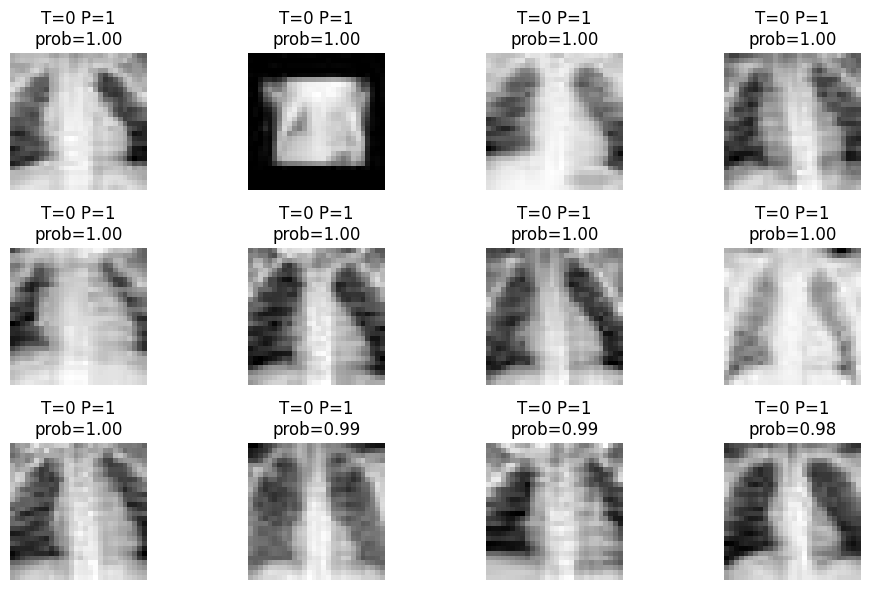

In [13]:
# Failure cases image grid

# Collect misclassified examples
# We need the raw test images too, so we iterate through test_dataset directly.

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified count:", len(mis_idx))

# Take top 12 highest-confidence wrong predictions
# Confidence = probability if predicted 1, else (1 - probability) if predicted 0
conf = np.where(y_pred == 1, y_prob, 1 - y_prob)
mis_conf = conf[mis_idx]
top = mis_idx[np.argsort(-mis_conf)][:12]

# Plot grid
plt.figure(figsize=(10, 6))
for i, idx in enumerate(top):
    img, label = test_dataset[idx]
    # img is tensor [1,28,28]
    img_np = img.squeeze(0).numpy()

    plt.subplot(3, 4, i+1)
    plt.imshow(img_np, cmap="gray")
    plt.axis("off")
    plt.title(f"T={int(y_true[idx])} P={int(y_pred[idx])}\nprob={y_prob[idx]:.2f}")

plt.tight_layout()
plt.savefig("reports/task1/failure_cases.png", dpi=200)
plt.show()